# Project FORESIGHT

## Phase 9: Baseline Forecasting

### Objective

Build a baseline demand forecasting model to establish benchmark performance before training advanced machine learning models.

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

import joblib

import warnings
warnings.filterwarnings("ignore")

In [14]:
df = pd.read_csv("../data/processed/feature_engineered_dataset.csv")

df["date"] = pd.to_datetime(df["date"])

print("Dataset Loaded Successfully")

print(df.shape)

df.head()

Dataset Loaded Successfully
(73000, 24)


,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,...,is_holiday,promo_event,on_hand_units,on_order_units,lead_time_days,reorder_point,day,day_of_week,quarter,year
0,2024-01-01,SKU001,16,3814.08,238.38,0,Appliances,General,2023-01-01,173,...,0,NaN,171.0,95.0,13.0,71.0,1,0,1,2024
1,2024-01-01,SKU002,9,943.65,104.85,0,Furniture,General,2023-01-01,72,...,0,NaN,78.0,59.0,5.0,29.0,1,0,1,2024
2,2024-01-01,SKU003,14,4658.92,332.78,0,Furniture,General,2023-01-01,183,...,0,NaN,135.0,86.0,15.0,74.0,1,0,1,2024
3,2024-01-01,SKU004,11,2825.35,256.85,0,Furniture,General,2023-01-01,161,...,0,NaN,207.0,11.0,15.0,20.0,1,0,1,2024
4,2024-01-01,SKU005,12,575.40,47.95,0,Furniture,General,2023-01-01,33,...,0,NaN,155.0,68.0,6.0,49.0,1,0,1,2024


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73000 entries, 0 to 72999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            73000 non-null  datetime64[us]
 1   sku_id          73000 non-null  str           
 2   units_sold      73000 non-null  int64         
 3   revenue         73000 non-null  float64       
 4   unit_price      73000 non-null  float64       
 5   promo_flag      73000 non-null  int64         
 6   category        73000 non-null  str           
 7   subcategory     73000 non-null  str           
 8   launch_date     73000 non-null  str           
 9   unit_cost       73000 non-null  int64         
 10  list_price      73000 non-null  float64       
 11  week            73000 non-null  int64         
 12  month           73000 non-null  int64         
 13  season          73000 non-null  str           
 14  is_holiday      73000 non-null  int64         
 15  promo_event  

In [16]:
df.isnull().sum()

date                  0
sku_id                0
units_sold            0
revenue               0
unit_price            0
promo_flag            0
category              0
subcategory           0
launch_date           0
unit_cost             0
list_price            0
week                  0
month                 0
season                0
is_holiday            0
promo_event       71400
on_hand_units     63400
on_order_units    63400
lead_time_days    63400
reorder_point     63400
day                   0
day_of_week           0
quarter               0
year                  0
dtype: int64

In [17]:
features = [
    "unit_price",
    "promo_flag",
    "unit_cost",
    "list_price",
    "week",
    "month",
    "is_holiday",
    "day",
    "day_of_week",
    "quarter",
    "year",
    "on_hand_units",
    "on_order_units",
    "lead_time_days",
    "reorder_point"
]

target = "units_sold"

In [18]:
model_data = df[features + [target]].copy()

model_data.head()

,unit_price,promo_flag,unit_cost,list_price,week,month,is_holiday,day,day_of_week,quarter,year,on_hand_units,on_order_units,lead_time_days,reorder_point,units_sold
0,238.38,0,173,238.38,1,1,0,1,0,1,2024,171.0,95.0,13.0,71.0,16
1,104.85,0,72,104.85,1,1,0,1,0,1,2024,78.0,59.0,5.0,29.0,9
2,332.78,0,183,332.78,1,1,0,1,0,1,2024,135.0,86.0,15.0,74.0,14
3,256.85,0,161,256.85,1,1,0,1,0,1,2024,207.0,11.0,15.0,20.0,11
4,47.95,0,33,47.95,1,1,0,1,0,1,2024,155.0,68.0,6.0,49.0,12


In [19]:
model_data.fillna(0, inplace=True)

model_data.isnull().sum()

unit_price        0
promo_flag        0
unit_cost         0
list_price        0
week              0
month             0
is_holiday        0
day               0
day_of_week       0
quarter           0
year              0
on_hand_units     0
on_order_units    0
lead_time_days    0
reorder_point     0
units_sold        0
dtype: int64

In [20]:
X = model_data[features]

y = model_data[target]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (73000, 15)
Target Shape : (73000,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (58400, 15)
Testing Data : (14600, 15)


In [23]:
from sklearn.ensemble import RandomForestRegressor

baseline_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)

print("Baseline Model Trained Successfully")

Baseline Model Trained Successfully


In [24]:
y_pred = baseline_model.predict(X_test)

print(y_pred[:10])

[12.15 11.84 10.78  9.7  13.11  9.75 11.1  12.83 12.26 10.58]


In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 40)
print("Baseline Model Performance")
print("=" * 40)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Baseline Model Performance
MAE  : 3.36
RMSE : 4.21
R²   : 0.0075


In [26]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": baseline_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,unit_cost,0.156057
7,day,0.152885
0,unit_price,0.125769
3,list_price,0.125296
1,promo_flag,0.104862
4,week,0.094872
8,day_of_week,0.087831
5,month,0.050351
11,on_hand_units,0.021655
12,on_order_units,0.020290


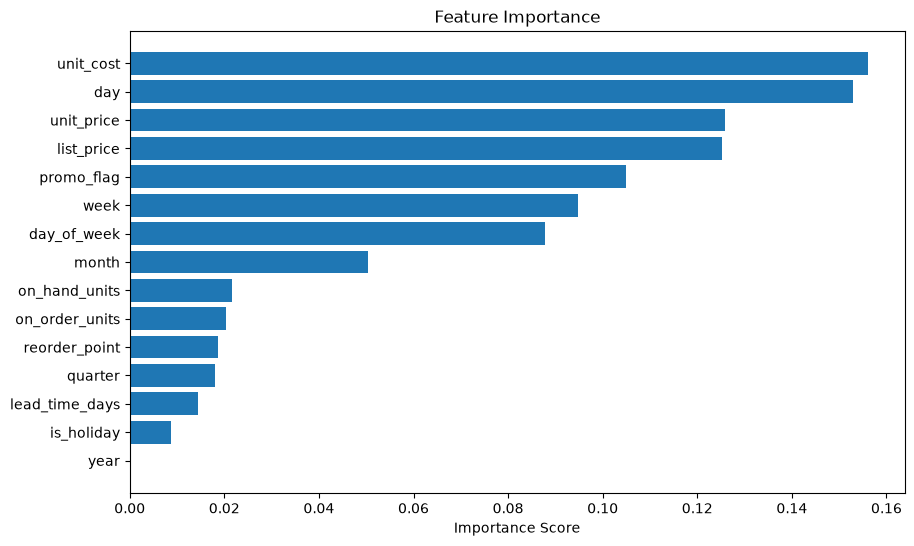

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.show()

In [29]:
import joblib

joblib.dump(
    baseline_model,
    "../models/baseline_random_forest.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [30]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.to_csv(
    "../reports/baseline_predictions.csv",
    index=False
)

print("Prediction Results Saved Successfully")

Prediction Results Saved Successfully


In [31]:
import joblib

model = joblib.load("../models/baseline_random_forest.pkl")

print(type(model))
print(model)

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
RandomForestRegressor(n_jobs=-1, random_state=42)
